### Steps for ANN
1. Load the data
2. convert data to Tensors
3. now for that tensors we create TensorDataset and DataLoader
4. Define ANN model
5. train the model and save the model
6. Evaluate

NOTE -> in ANN we always scale our data because while calculating z it will get biased if any feature has higher scale 

In [95]:
import pandas as pd
import numpy as np

In [96]:
df = pd.read_csv("powerplant_data.csv")

In [97]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [98]:
# AT -> temperature in power plant
# v -> vaccum in power plant
# AP -> pressure in power plant
# RH -> humidity in power plant

# PE -> produced energy

In [99]:
df.shape

(9568, 5)

In [100]:
df.isnull().sum() 

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [101]:
# data is already cleaned there is no missing values and every column is numeric so now load data in X (input) y (output)

In [102]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [103]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [104]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [105]:
# Split our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [106]:
# Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
# start converting our data into tensors
''' 
Tensors are core datastructure of pytorch 
pytorch can autamatically perform many calculations
of ANN if data is in tensor in deep learning we always 
convert our data into tensor
'''

import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32) # it is a numpy array so we do not need to pass values actually after scaling it got  converted to numpy array
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1) # because it is not an array we are passing .values

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32) # after scalling X_test_scaled got converted to numpy array so we do not need to write .values
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1) # because it is not an array it is a pandas series 

# .view because y_train shape is like [1,2,3,4] (one row) currently but we want it to be like [[1],[2],[3]] (multiple row , 1 column)  so .view(number of rows,number oof column ) we want 1 column so pass 1 and adjustable rows according to y_train so -1 thats why .view(-1,1)

In [108]:
type(X_train_scaled)

numpy.ndarray

In [109]:
type(y_train)

pandas.core.series.Series

In [110]:
# Dataloader class ->
''' 
it creates batches for us + shuffle(optional)
to define how the data will be loaded for training
 '''

# Tensor Dataset class ->
''' 
it is a helper class of dataloader class
the raw tensor data is stored in memory which cant be accessed 
directly by dataloader class so tensor dataset class picks 
the data from memory and give it to dataloader class to create 
batches it can also acces and pass on one sample at a time
'''

from torch.utils.data import TensorDataset , DataLoader

# create dataset from tensordataset so we can pass it to dataloader to create batches since dataloader cant access tensor data directly from memory but tensordataset can
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

# Deep Learning

In [111]:
# define our ANN model 
''' 
we build a ANN model in the form of a class and that class
is build on the top of a base class called nn.module
'''

class ANN(nn.Module):
    def __init__(self):  # it is a constructer class and in constructor class we call the class itslef and build model
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # we not need to define input layer because how many inputs are going to have will have been  defined in 1st hidden layer
            
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6,1),
        )  # we are passing all of the linear relu as parameter

    def forward(self,x): # define Forward Propagation logic and this logic is already defined in self.model so we return self.model with x as a input
        return self.model(x)
    
    # and backward propagation is handeled by pytorch inside pytorch we have Autograd who handle backward propogation

In [112]:
# now we are going to build actual model which will be object of ANN class

model = ANN()

# we also need to define which loss function and optimizer we want to use

import torch.optim as optim

criterion =  nn.MSELoss()  # loss function
optimizer = optim.Adam(model.parameters()) # optimizer # we pass paramater of model like weight bias etc which is already defined in class by nn.module

In [113]:
# Training model
''' 
we are going to train our modle in 100 epoch where in each epoch
there will be multiple batches and in each batch we are going to do 
forward backward propagation
'''
train_losses = []
valid_losses = []
best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):

    # training
    model.train() # we are setting up model in training phase so that it will be going to train from input dataset
    running_loss = 0.0

    for xb,yb in train_loader: # dataloader has created multiple batches and stored in train_loader so now we are going to train our model on that batches one by one
        # xb = features of I batch
        # yb = labels of I batch
        optimizer.zero_grad() # to remove old gradient so that in next iteration old gradient will not be going to use

        outputs = model(xb) #forward pop ... predicted ouputs for this batch
        loss = criterion(outputs,yb) # compute loss
        loss.backward() # back pop... campute gradient
        optimizer.step() # param update 
        running_loss+=loss.item() # loss is a tensor => py float

    epoch_training_loss = running_loss/len(train_loader)
    train_losses.append(epoch_training_loss)

    # validation
    model.eval() # we are setting up our model to evluation mode to do validation 
    running_val_loss = 0.0

    with torch.no_grad(): # always write in validation and testing so that unnacessary gradients calculate na ho # here we tell pytorch that here we are not going to compute gradient since it is validation we are going to perform because by default pytorch cumputes gradient automated gradient computation hota hai by writing this we are going to save memory because all gradient will going to compute and save in memory and we are speeding up remaining computations
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss+=loss.item()

    epoch_validation_loss = running_val_loss/len(test_loader)
    valid_losses.append(epoch_validation_loss)
    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_training_loss} & val loss = {epoch_validation_loss}")

    if epoch_validation_loss<best_val_loss:
        best_val_loss=epoch_validation_loss
        torch.save(model.state_dict(),"best_model.pt") # .pt or .pth are extensions to save model # here we are saving the learning parameters 

epoch 1/100 ==> training loss = 206352.36875 & val loss = 205210.52604166666
epoch 2/100 ==> training loss = 201356.85553385416 & val loss = 194208.83098958334
epoch 3/100 ==> training loss = 180557.25657552082 & val loss = 162925.42239583333
epoch 4/100 ==> training loss = 140079.82444661457 & val loss = 115394.50533854167
epoch 5/100 ==> training loss = 90683.19733072916 & val loss = 67575.90625
epoch 6/100 ==> training loss = 50087.609436035156 & val loss = 36246.26227213542
epoch 7/100 ==> training loss = 28472.022241210936 & val loss = 22924.590185546876
epoch 8/100 ==> training loss = 20239.069669596352 & val loss = 17998.47491861979
epoch 9/100 ==> training loss = 16664.53878173828 & val loss = 15018.854313151041
epoch 10/100 ==> training loss = 13796.135046386718 & val loss = 12345.1021484375
epoch 11/100 ==> training loss = 11179.903397623699 & val loss = 9829.104679361979
epoch 12/100 ==> training loss = 8785.2314453125 & val loss = 7520.708357747396
epoch 13/100 ==> training

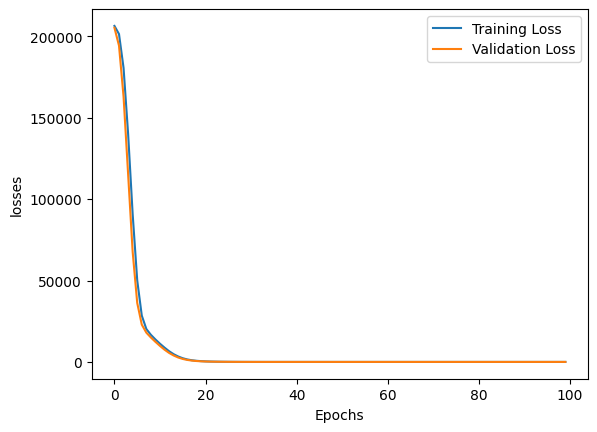

In [114]:
import matplotlib.pyplot as plt

loss_df= pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":valid_losses
})

plt.plot(loss_df["Training Loss"],label = "Training Loss")
plt.plot(loss_df["Validation Loss"],label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()
plt.show()

In [115]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))  # torch.load("best_model.pt") -> it loads the saved learning parameter and model.load_state_dict() -> it adds that inside model 

<All keys matched successfully>

In [116]:
# Evaluate our Model

model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)  # now no need to do batch wise do together we are not training or validating here so we need to do batch wise we are testing so we test in whole training data and whole testing data so we pass all at ones not in batches like we were doing while training our model
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor)
    test_mse_loss = criterion(test_preds,y_test_tensor)

print("Training MSE : ",train_mse_loss.item())
print("Testing MSE : ",test_mse_loss.item())

Training MSE :  20.236244201660156
Testing MSE :  18.57912826538086


In [117]:
from sklearn.metrics import r2_score

print("r^2 score = ",r2_score(y_test,test_preds))

r^2 score =  0.9350707392127822
